In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, random, cv2, time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, classification_report, accuracy_score
)

In [ ]:
X = np.load("/content/drive/MyDrive/Lanedetection/image_mixed.npy")
Y = np.load("/content/drive/MyDrive/Lanedetection/label_mixed.npy")

print("Original shapes:", X.shape, Y.shape)

Original shapes: (14999, 80, 160, 3) (14999, 80, 160)


In [ ]:
X = X.astype(np.float32) / 255.0
Y = (Y > 0.5).astype(np.float32)
if len(Y.shape) == 3:
    Y = np.expand_dims(Y, axis=-1)

print("After preprocessing → unique labels:", np.unique(Y))

After preprocessing → unique labels: [0. 1.]


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)
print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (11999, 80, 160, 3) Val: (3000, 80, 160, 3)


In [ ]:
def dsc(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0, 1)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2. * inter + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dsc(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(y_pred, 0, 1)), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(y_pred, 0, 1)), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

In [ ]:
# ================= CBAM MODULE =================

def channel_attention(x, ratio=8):
    """Channel Attention: learns WHAT to focus on"""
    ch = x.shape[-1]

    shared_dense1 = Dense(ch // ratio, activation='relu')
    shared_dense2 = Dense(ch)

    # Average Pool branch
    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Reshape((1, 1, ch))(avg_pool)
    avg_pool = shared_dense1(avg_pool)
    avg_pool = shared_dense2(avg_pool)

    # Max Pool branch
    max_pool = GlobalMaxPooling2D()(x)
    max_pool = Reshape((1, 1, ch))(max_pool)
    max_pool = shared_dense1(max_pool)
    max_pool = shared_dense2(max_pool)

    # Combine and apply sigmoid
    out = Add()([avg_pool, max_pool])
    out = Activation('sigmoid')(out)

    return Multiply()([x, out])


def spatial_attention(x, kernel_size=7):
    """Spatial Attention: learns WHERE to focus on"""
    # Define a helper function for output shape inference
    def get_output_shape(input_shape):
        return input_shape[:-1] + (1,)

    avg_pool = Lambda(
        lambda t: tf.reduce_mean(t, axis=-1, keepdims=True),
        output_shape=get_output_shape
    )(x)
    max_pool = Lambda(
        lambda t: tf.reduce_max(t, axis=-1, keepdims=True),
        output_shape=get_output_shape
    )(x)

    concat = Concatenate()([avg_pool, max_pool])
    out = Conv2D(1, kernel_size, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, out])


def cbam_block(x, ratio=8, kernel_size=7):
    """Full CBAM = Channel Attention → Spatial Attention"""
    x = channel_attention(x, ratio)
    x = spatial_attention(x, kernel_size)
    return x

print("✅ CBAM module defined")

✅ CBAM module defined


In [ ]:
def LLDNet_CBAM(shape):
    inp = Input(shape)

    # -------- Encoder Block 1 --------
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inp)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    c1 = cbam_block(c1)
    p1 = MaxPooling2D()(c1)

    # -------- Encoder Block 2 --------
    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    c2 = cbam_block(c2)
    p2 = MaxPooling2D()(c2)

    # -------- Bottleneck --------
    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    c3 = cbam_block(c3)

    # -------- Decoder Block 1 --------
    u1 = UpSampling2D()(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(64, 3, activation='relu', padding='same')(u1)
    c4 = cbam_block(c4)

    # -------- Decoder Block 2 --------
    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = cbam_block(c5)

    # -------- Output --------
    out = Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inp, out, name="LLDNet_CBAM")

model = LLDNet_CBAM((X.shape[1], X.shape[2], X.shape[3]))
model.summary()

Model: "LLDNet_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 80, 160,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 160,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 80, 160,   │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv2d_1[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 4)   │        132 │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 32)  │        160 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 32)  │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1, 1, 32)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 80, 160,   │          0 │ conv2d_1[0][0],   │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 80, 160,   │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 80, 160,   │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80, 160,   │          0 │ lambda[0][0],     │
│ (Concatenate)       │ 2)                │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 160,   │         99 │ concatenate[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 80, 160,   │          0 │ multiply[0][0],   │
│ (Multiply)          │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 432,888 (1.65 MB)

 Trainable params: 432,888 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)

model.compile(
    optimizer=opt,
    loss=bce_dice_loss,
    metrics=["accuracy", iou_metric, dice_metric]
)

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=25,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.8878 - dice_metric: 0.6975 - iou_metric: 0.5868 - loss: 0.5828 - val_accuracy: 0.9419 - val_dice_metric: 0.8686 - val_iou_metric: 0.7688 - val_loss: 0.3294 - learning_rate: 1.0000e-04
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9521 - dice_metric: 0.8969 - iou_metric: 0.8143 - loss: 0.2690 - val_accuracy: 0.9607 - val_dice_metric: 0.9079 - val_iou_metric: 0.8323 - val_loss: 0.2461 - learning_rate: 1.0000e-04
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9663 - dice_metric: 0.9265 - iou_metric: 0.8638 - loss: 0.1959 - val_accuracy: 0.9709 - val_dice_metric: 0.9341 - val_iou_metric: 0.8769 - val_loss: 0.1710 - learning_rate: 1.0000e-04
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9721 - dice_metric: 0.9386 - iou_metric: 0.8848 - loss: 0.1622 - val_accuracy: 0.9746 - val_dice_metric: 0.9418 - val_iou_metric: 0.8904 - val_loss: 0.1484 - learning_r

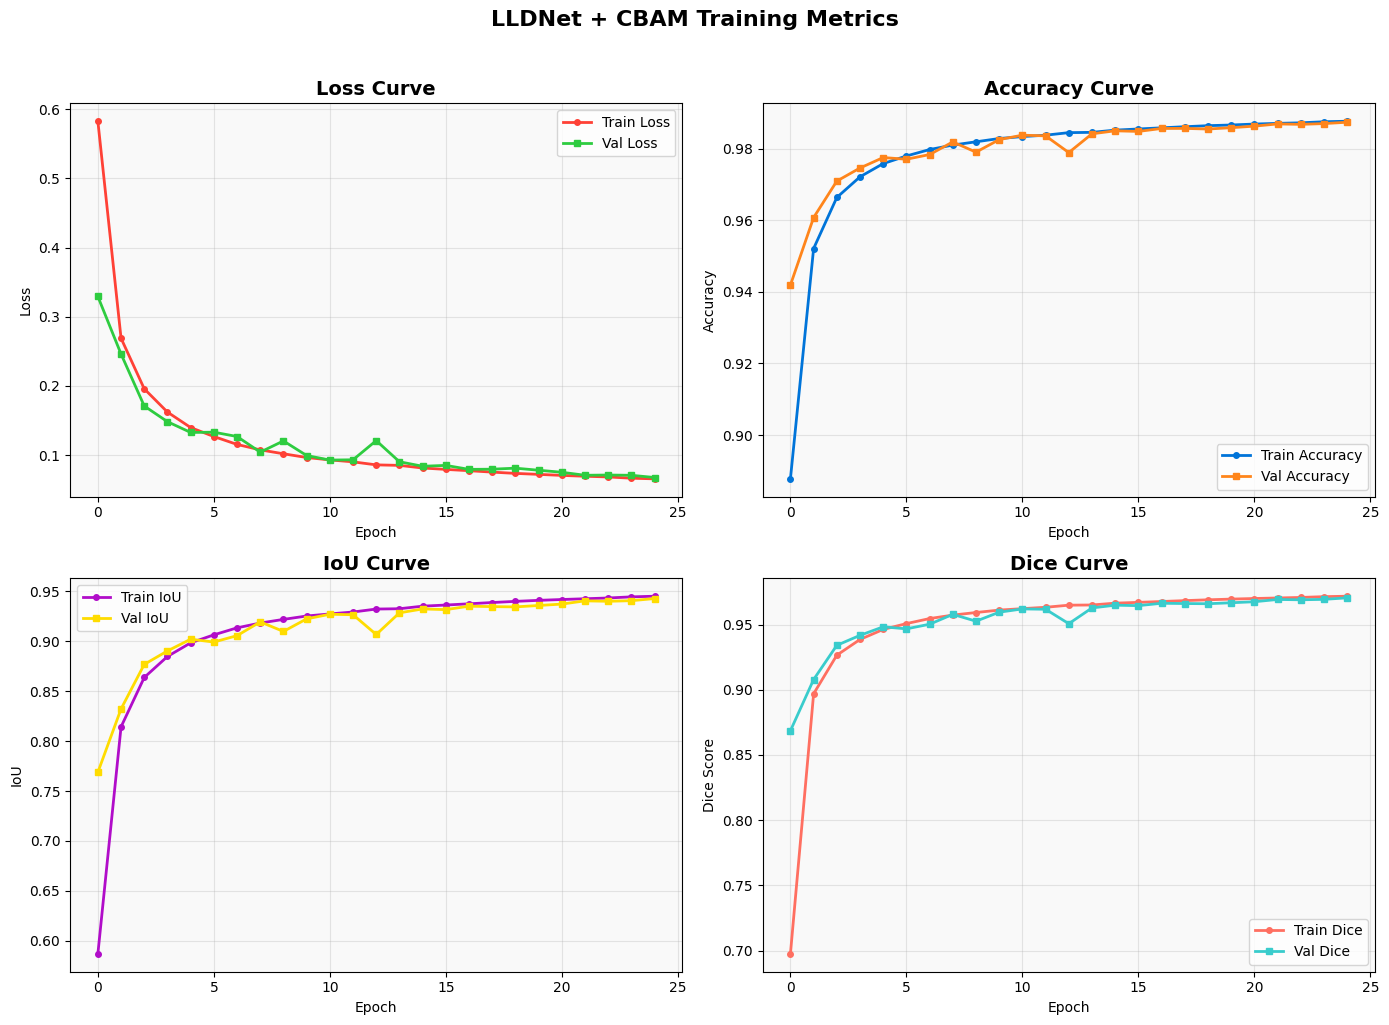

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------- Loss ----------
axes[0, 0].plot(history.history['loss'], label='Train Loss',
                color='#FF4136', linewidth=2, marker='o', markersize=4)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss',
                color='#2ECC40', linewidth=2, marker='s', markersize=4)
axes[0, 0].set_title("Loss Curve", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_facecolor('#f9f9f9')

# ---------- Accuracy ----------
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy',
                color='#0074D9', linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy',
                color='#FF851B', linewidth=2, marker='s', markersize=4)
axes[0, 1].set_title("Accuracy Curve", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_facecolor('#f9f9f9')

# ---------- IoU ----------
axes[1, 0].plot(history.history['iou_metric'], label='Train IoU',
                color='#B10DC9', linewidth=2, marker='o', markersize=4)
axes[1, 0].plot(history.history['val_iou_metric'], label='Val IoU',
                color='#FFDC00', linewidth=2, marker='s', markersize=4)
axes[1, 0].set_title("IoU Curve", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("IoU")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_facecolor('#f9f9f9')

# ---------- Dice ----------
axes[1, 1].plot(history.history['dice_metric'], label='Train Dice',
                color='#FF6F61', linewidth=2, marker='o', markersize=4)
axes[1, 1].plot(history.history['val_dice_metric'], label='Val Dice',
                color='#39CCCC', linewidth=2, marker='s', markersize=4)
axes[1, 1].set_title("Dice Curve", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Dice Score")
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_facecolor('#f9f9f9')

plt.suptitle("LLDNet + CBAM Training Metrics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("training_curves_cbam.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
metrics_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Train Loss': history.history['loss'],
    'Val Loss': history.history['val_loss'],
    'Train Acc': history.history['accuracy'],
    'Val Acc': history.history['val_accuracy'],
    'Train IoU': history.history['iou_metric'],
    'Val IoU': history.history['val_iou_metric'],
    'Train Dice': history.history['dice_metric'],
    'Val Dice': history.history['val_dice_metric']
})

# Style the dataframe
styled = metrics_df.style.background_gradient(
    cmap='RdYlGn', subset=['Val Acc', 'Val IoU', 'Val Dice']
).background_gradient(
    cmap='RdYlGn_r', subset=['Train Loss', 'Val Loss']
).format(precision=4)

display(styled)

,Epoch,Train Loss,Val Loss,Train Acc,Val Acc,Train IoU,Val IoU,Train Dice,Val Dice
0,1,0.5828,0.3294,0.8878,0.9419,0.5868,0.7688,0.6975,0.8686
1,2,0.2690,0.2461,0.9521,0.9607,0.8143,0.8323,0.8969,0.9079
2,3,0.1959,0.1710,0.9663,0.9709,0.8638,0.8769,0.9265,0.9341
3,4,0.1622,0.1484,0.9721,0.9746,0.8848,0.8904,0.9386,0.9418
4,5,0.1399,0.1328,0.9758,0.9775,0.8985,0.9021,0.9463,0.9483
5,6,0.1269,0.1332,0.9779,0.9770,0.9065,0.8993,0.9508,0.9467
6,7,0.1155,0.1269,0.9797,0.9783,0.9135,0.9057,0.9546,0.9503
7,8,0.1076,0.1043,0.9810,0.9819,0.9183,0.9195,0.9573,0.9579
8,9,0.1020,0.1205,0.9819,0.9790,0.9220,0.9099,0.9593,0.9526
9,10,0.0966,0.0994,0.9828,0.9825,0.9254,0.9225,0.9611,0.9595


In [ ]:
summary = metrics_df.drop(columns=['Epoch']).mean().to_frame(name='Average').T
summary_styled = summary.style.background_gradient(
    cmap='Blues'
).format(precision=4)

display(summary_styled)

# Also print best epoch values
best_epoch = metrics_df.loc[metrics_df['Val Loss'].idxmin()]
print("\n🏆 Best Epoch (lowest val loss):")
print(best_epoch.to_string())

,Train Loss,Val Loss,Train Acc,Val Acc,Train IoU,Val IoU,Train Dice,Val Dice
Average,0.1221,0.1141,0.9778,0.9800,0.9081,0.9129,0.9483,0.9538



🏆 Best Epoch (lowest val loss):
Epoch         25.000000
Train Loss     0.065711
Val Loss       0.067643
Train Acc      0.987635
Val Acc        0.987350
Train IoU      0.945222
Val IoU        0.942873
Train Dice     0.971762
Val Dice       0.970512


94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step


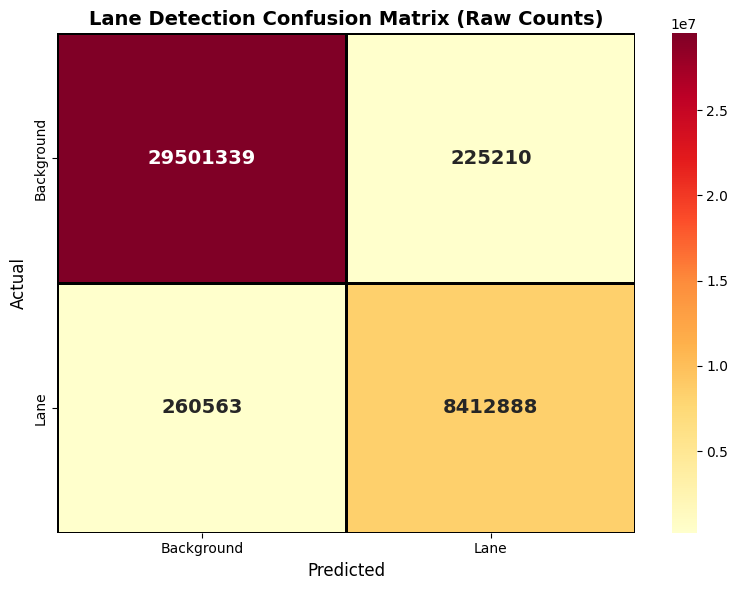

In [ ]:
preds = model.predict(X_val, verbose=1)
preds_bin = (preds > 0.5).astype(np.uint8)

y_true_flat = Y_val.flatten().astype(np.uint8)
y_pred_flat = preds_bin.flatten().astype(np.uint8)

cm = confusion_matrix(y_true_flat, y_pred_flat)

# ---------- Confusion Matrix Raw ----------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=['Background', 'Lane'],
    yticklabels=['Background', 'Lane'],
    linewidths=2, linecolor='black',
    annot_kws={"size": 14, "fontweight": "bold"}
)
plt.title("Lane Detection Confusion Matrix (Raw Counts)",
          fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_raw.png", dpi=300)
plt.show()

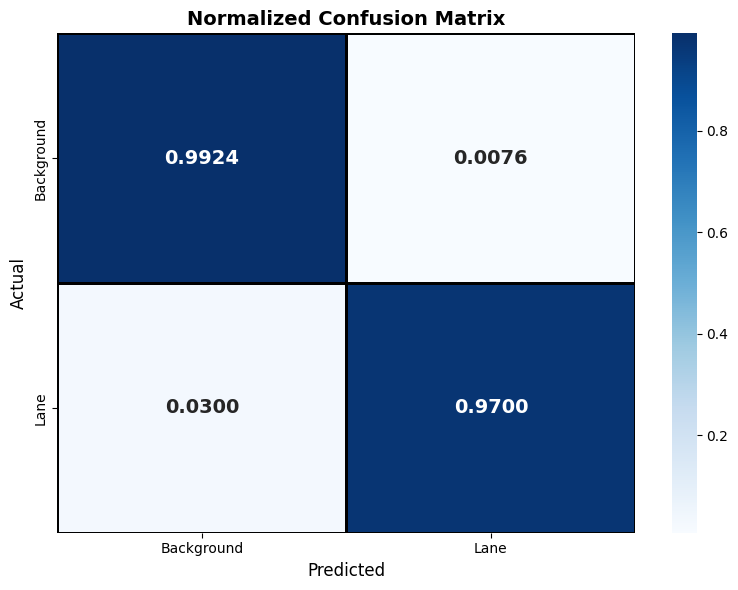

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm, annot=True, fmt='.4f', cmap='Blues',
    xticklabels=['Background', 'Lane'],
    yticklabels=['Background', 'Lane'],
    linewidths=2, linecolor='black',
    annot_kws={"size": 14, "fontweight": "bold"}
)
plt.title("Normalized Confusion Matrix",
          fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=300)
plt.show()

In [ ]:
acc = accuracy_score(y_true_flat, y_pred_flat)
prec = precision_score(y_true_flat, y_pred_flat, zero_division=0)
rec = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

# IoU from confusion matrix
tn, fp, fn, tp = cm.ravel()
iou = tp / (tp + fp + fn + 1e-6)
dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
specificity = tn / (tn + fp + 1e-6)

print("=" * 50)
print("   LLDNet + CBAM | Pixel-Level Metrics")
print("=" * 50)
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {prec:.4f}")
print(f"   Recall       : {rec:.4f}")
print(f"   F1 Score     : {f1:.4f}")
print(f"   IoU          : {iou:.4f}")
print(f"   Dice Score   : {dice:.4f}")
print(f"   Specificity  : {specificity:.4f}")
print("=" * 50)

   LLDNet + CBAM | Pixel-Level Metrics
   Accuracy     : 0.9873
   Precision    : 0.9739
   Recall       : 0.9700
   F1 Score     : 0.9719
   IoU          : 0.9454
   Dice Score   : 0.9719
   Specificity  : 0.9924


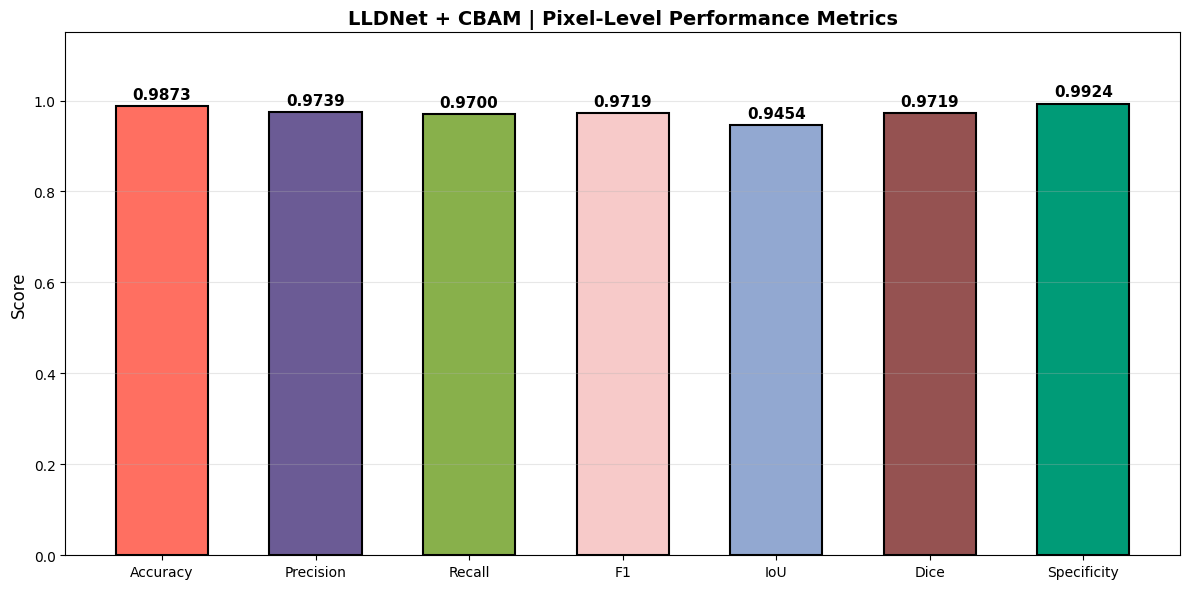

In [ ]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'IoU', 'Dice', 'Specificity']
metric_values = [acc, prec, rec, f1, iou, dice, specificity]
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9',
          '#92A8D1', '#955251', '#009B77']

plt.figure(figsize=(12, 6))
bars = plt.bar(metric_names, metric_values, color=colors,
               edgecolor='black', linewidth=1.5, width=0.6)

for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.ylim(0, 1.15)
plt.title("LLDNet + CBAM | Pixel-Level Performance Metrics",
          fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("performance_bar_chart.png", dpi=300)
plt.show()

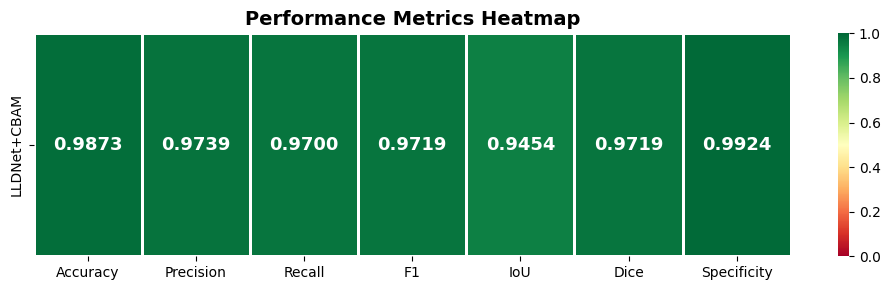

In [ ]:
perf_df = pd.DataFrame({
    'Metric': metric_names,
    'Score': metric_values
})

plt.figure(figsize=(10, 3))
sns.heatmap(
    perf_df[['Score']].T,
    annot=True, fmt='.4f', cmap='RdYlGn',
    xticklabels=metric_names,
    yticklabels=['LLDNet+CBAM'],
    linewidths=2, linecolor='white',
    annot_kws={"size": 13, "fontweight": "bold"},
    vmin=0, vmax=1
)
plt.title("Performance Metrics Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("performance_heatmap.png", dpi=300)
plt.show()

In [ ]:
report = classification_report(
    y_true_flat, y_pred_flat,
    target_names=['Background', 'Lane'],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
styled_report = report_df.style.background_gradient(
    cmap='Greens'
).format(precision=4)

display(styled_report)

,precision,recall,f1-score,support
Background,0.9912,0.9924,0.9918,29726549.0000
Lane,0.9739,0.9700,0.9719,8673451.0000
accuracy,0.9873,0.9873,0.9873,0.9873
macro avg,0.9826,0.9812,0.9819,38400000.0000
weighted avg,0.9873,0.9873,0.9873,38400000.0000


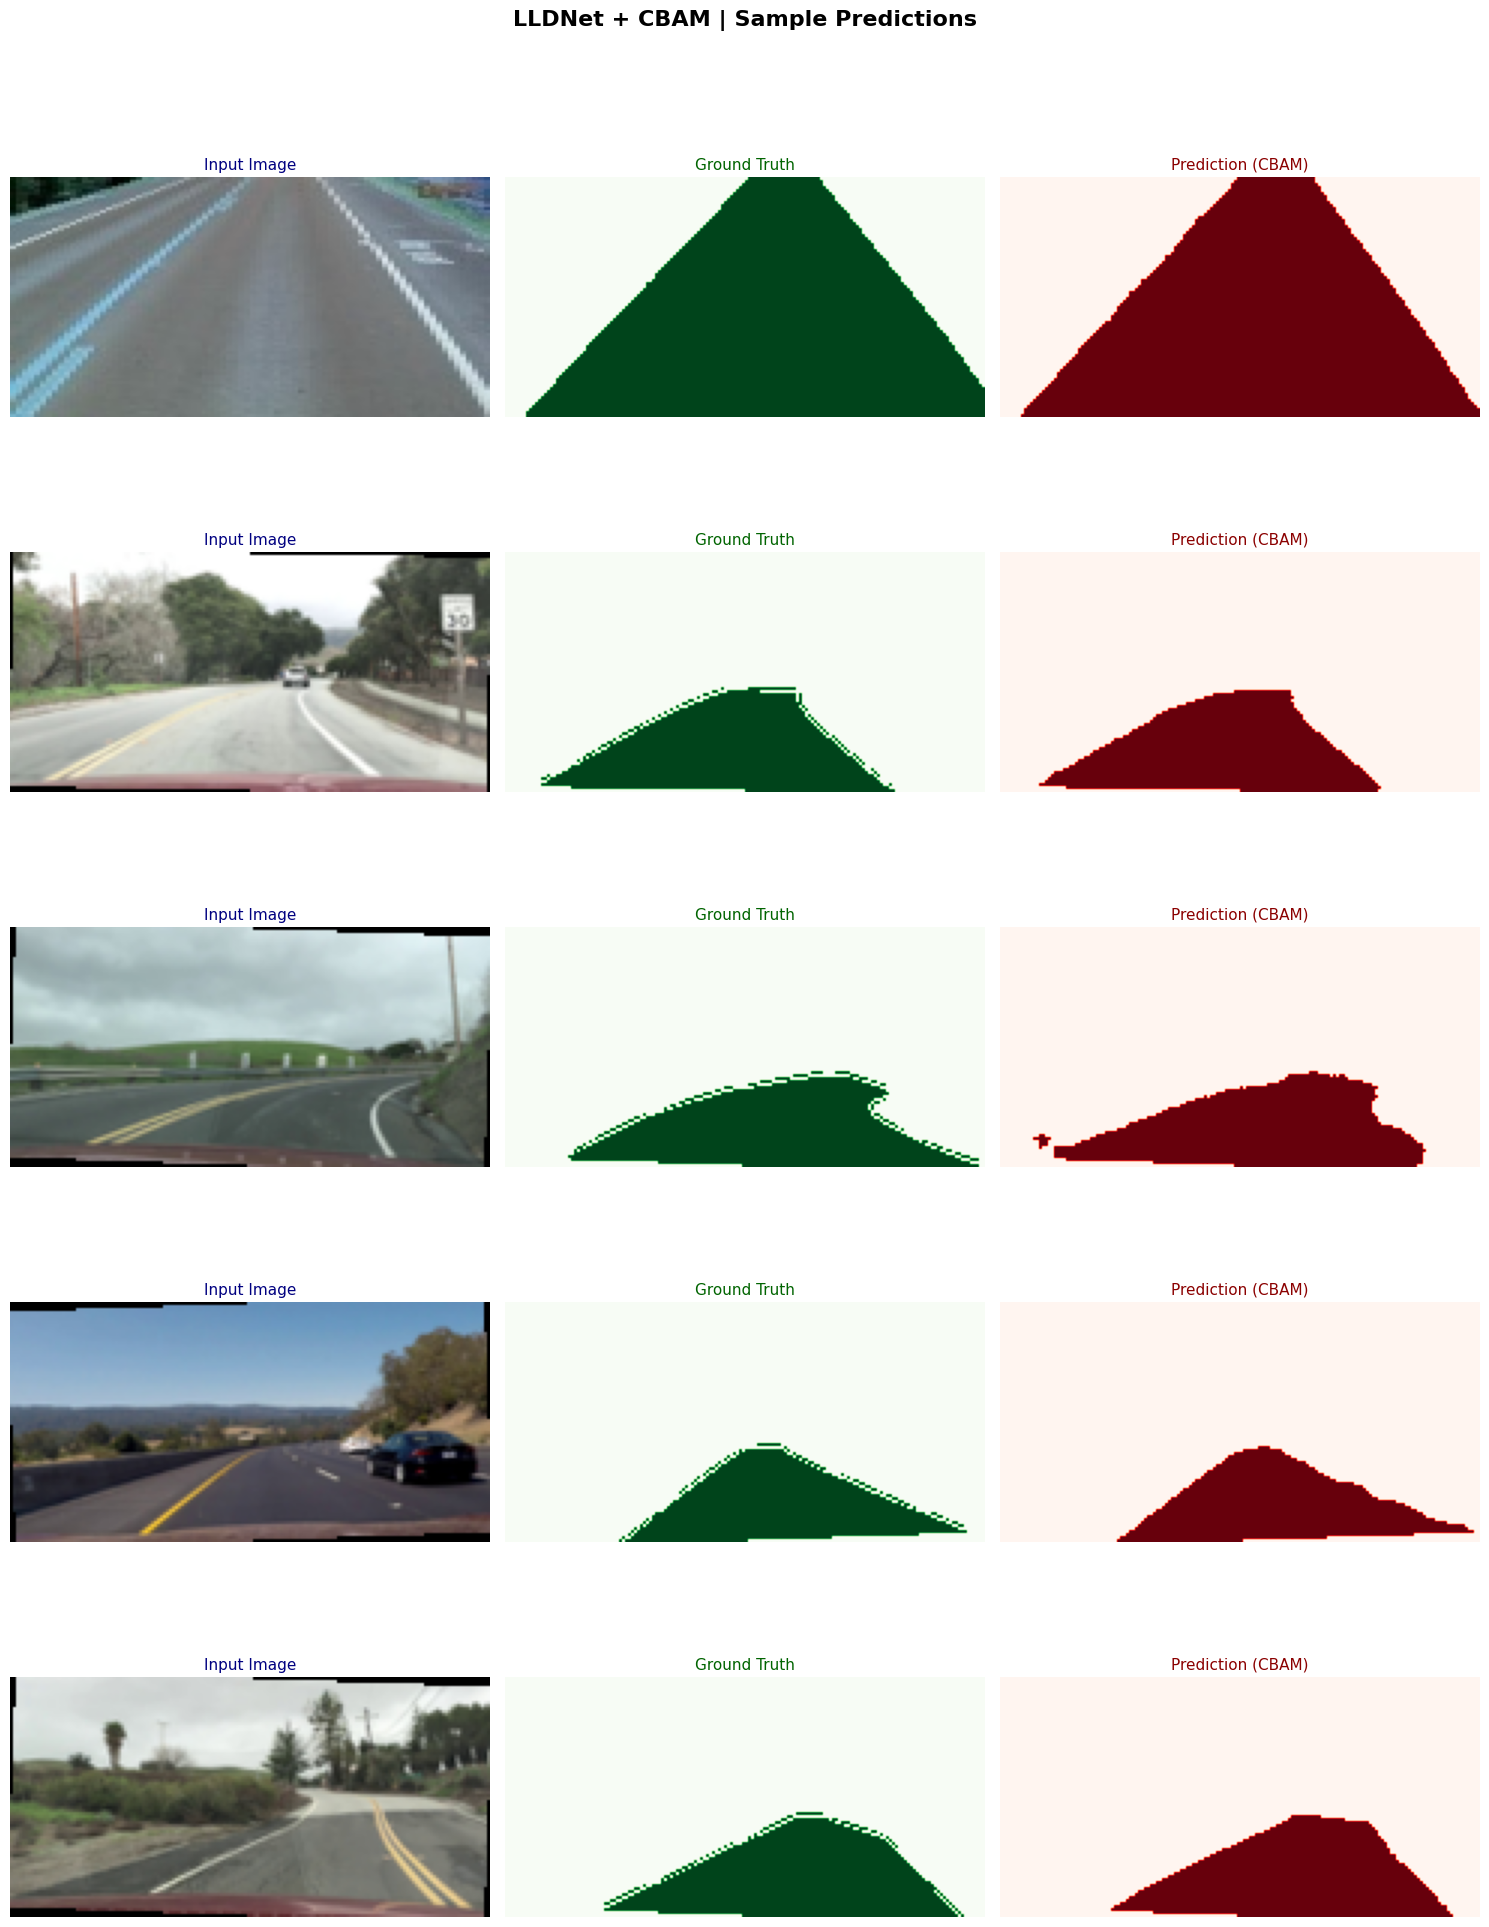

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(15, 20))

indices = random.sample(range(len(X_val)), 5)

for i, idx in enumerate(indices):
    # Original Image
    axes[i, 0].imshow(X_val[idx])
    axes[i, 0].set_title("Input Image", fontsize=11, color='navy')
    axes[i, 0].axis('off')

    # Ground Truth
    axes[i, 1].imshow(Y_val[idx, :, :, 0], cmap='Greens')
    axes[i, 1].set_title("Ground Truth", fontsize=11, color='darkgreen')
    axes[i, 1].axis('off')

    # Prediction
    axes[i, 2].imshow(preds_bin[idx, :, :, 0], cmap='Reds')
    axes[i, 2].set_title("Prediction (CBAM)", fontsize=11, color='darkred')
    axes[i, 2].axis('off')

plt.suptitle("LLDNet + CBAM | Sample Predictions",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("sample_predictions_cbam.png", dpi=300, bbox_inches='tight')
plt.show()

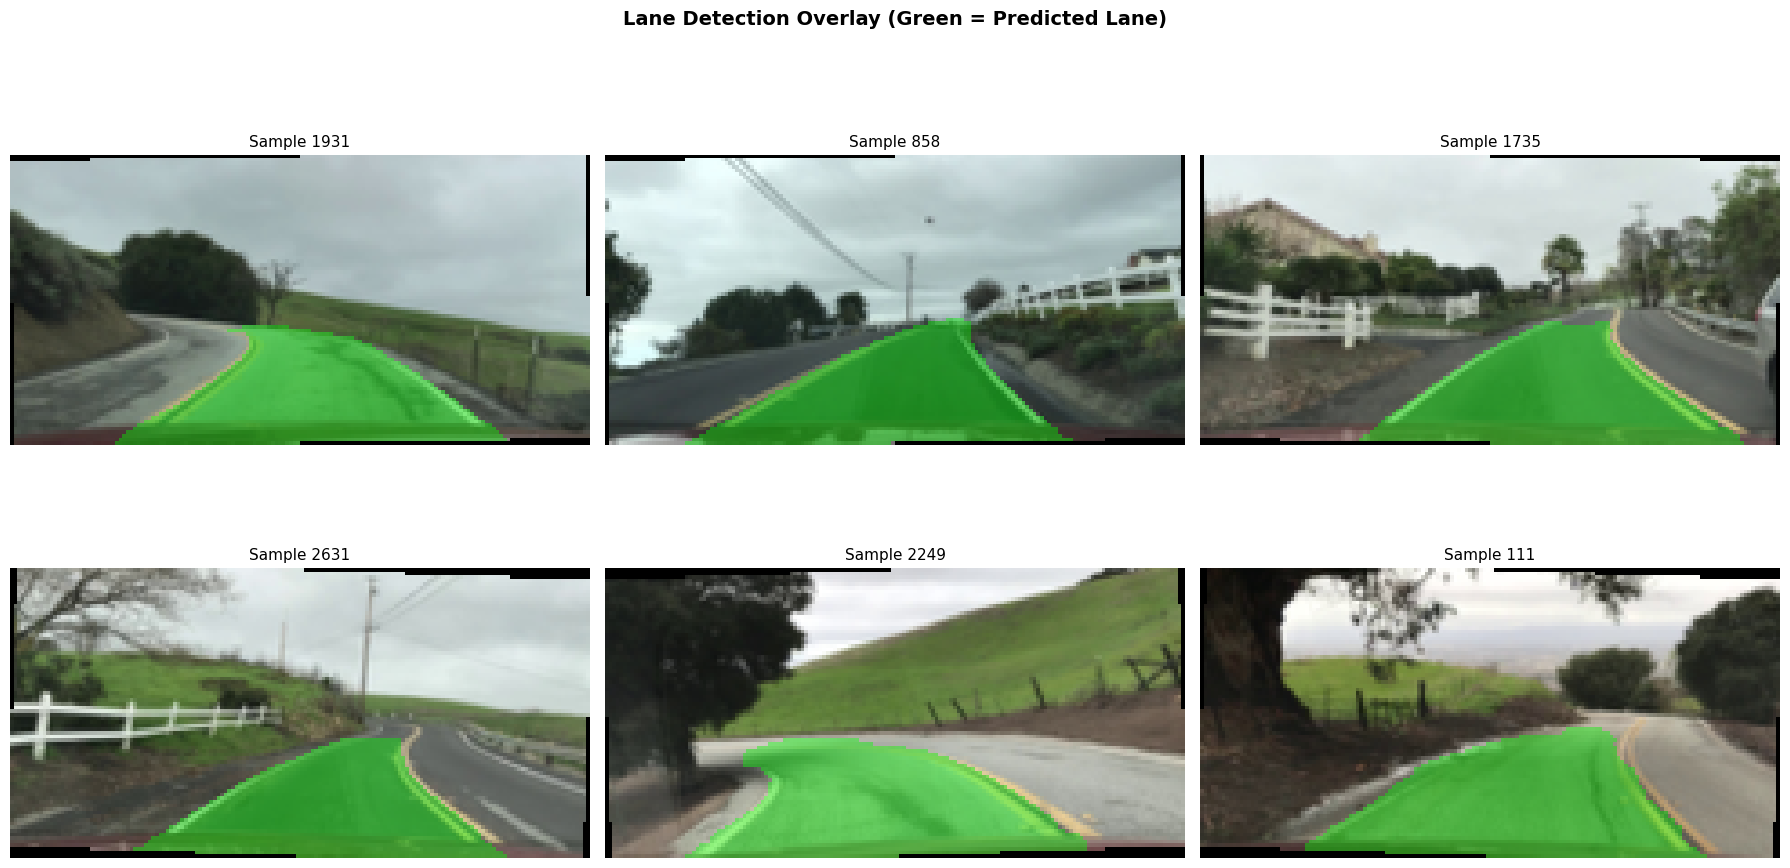

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

indices = random.sample(range(len(X_val)), 6)

for i, idx in enumerate(indices):
    row, col = i // 3, i % 3

    img = (X_val[idx] * 255).astype(np.uint8).copy()

    # Create colored overlay
    mask = preds_bin[idx, :, :, 0]
    overlay = img.copy()
    overlay[mask == 1] = [0, 255, 0]  # Green for lane

    # Blend
    blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

    axes[row, col].imshow(blended)
    axes[row, col].set_title(f"Sample {idx}", fontsize=11)
    axes[row, col].axis('off')

plt.suptitle("Lane Detection Overlay (Green = Predicted Lane)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("overlay_predictions.png", dpi=300, bbox_inches='tight')
plt.show()

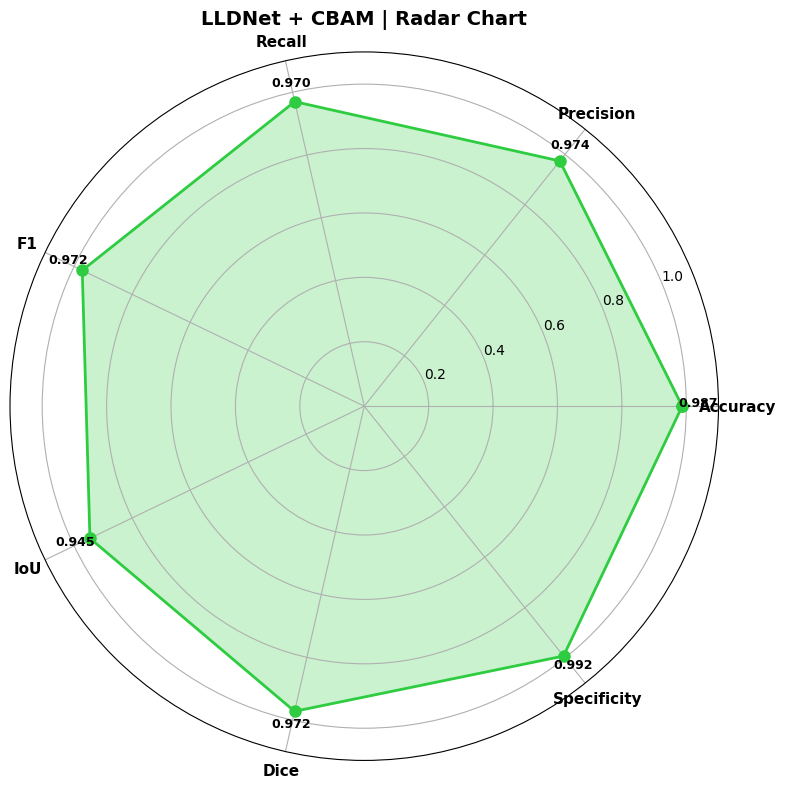

In [ ]:
from math import pi

categories = metric_names
values = metric_values + [metric_values[0]]  # close the loop

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.fill(angles, values, color='#2ECC40', alpha=0.25)
ax.plot(angles, values, color='#2ECC40', linewidth=2, marker='o', markersize=8)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title("LLDNet + CBAM | Radar Chart",
             fontsize=14, fontweight='bold', pad=20)

# Add value labels
for angle, value, name in zip(angles[:-1], values[:-1], categories):
    ax.text(angle, value + 0.05, f'{value:.3f}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("radar_chart.png", dpi=300)
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/Lanedetection/LLDNet_CBAM_trained.h5")
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
print("\n" + "=" * 60)
print("       🏆 LLDNet + CBAM | FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"   Total Parameters : {model.count_params():,}")
print(f"   Best Val Loss    : {metrics_df['Val Loss'].min():.4f}")
print(f"   Best Val Accuracy: {metrics_df['Val Acc'].max():.4f}")
print(f"   Best Val IoU     : {metrics_df['Val IoU'].max():.4f}")
print(f"   Best Val Dice    : {metrics_df['Val Dice'].max():.4f}")
print("-" * 60)
print(f"   Pixel Accuracy   : {acc:.4f}")
print(f"   Pixel Precision  : {prec:.4f}")
print(f"   Pixel Recall     : {rec:.4f}")
print(f"   Pixel F1 Score   : {f1:.4f}")
print(f"   Pixel IoU        : {iou:.4f}")
print(f"   Pixel Dice       : {dice:.4f}")
print(f"   Pixel Specificity: {specificity:.4f}")
print("=" * 60)
print("   ✅ CBAM Attention: Channel ✅ | Spatial ✅")
print("=" * 60)


       🏆 LLDNet + CBAM | FINAL RESULTS SUMMARY
   Total Parameters : 432,888
   Best Val Loss    : 0.0676
   Best Val Accuracy: 0.9873
   Best Val IoU     : 0.9429
   Best Val Dice    : 0.9705
------------------------------------------------------------
   Pixel Accuracy   : 0.9873
   Pixel Precision  : 0.9739
   Pixel Recall     : 0.9700
   Pixel F1 Score   : 0.9719
   Pixel IoU        : 0.9454
   Pixel Dice       : 0.9719
   Pixel Specificity: 0.9924
   ✅ CBAM Attention: Channel ✅ | Spatial ✅


In [ ]:
# ============================================================
#  LLDNet + CBAM — Video Inference Script (Google Colab)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from google.colab.patches import cv2_imshow
from IPython.display import HTML
from base64 import b64encode
import time

# ================= CUSTOM OBJECTS =================

def dsc(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0, 1)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2. * inter + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dsc(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(y_pred, 0, 1)), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(y_pred, 0, 1)), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

# ================= CBAM MODULE =================

def channel_attention(x, ratio=8):
    ch = x.shape[-1]
    shared_dense1 = Dense(ch // ratio, activation='relu')
    shared_dense2 = Dense(ch)

    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Reshape((1, 1, ch))(avg_pool)
    avg_pool = shared_dense1(avg_pool)
    avg_pool = shared_dense2(avg_pool)

    max_pool = GlobalMaxPooling2D()(x)
    max_pool = Reshape((1, 1, ch))(max_pool)
    max_pool = shared_dense1(max_pool)
    max_pool = shared_dense2(max_pool)

    out = Add()([avg_pool, max_pool])
    out = Activation('sigmoid')(out)
    return Multiply()([x, out])


def spatial_attention(x, kernel_size=7):
    def get_output_shape(input_shape):
        return input_shape[:-1] + (1,)

    avg_pool = Lambda(
        lambda t: tf.reduce_mean(t, axis=-1, keepdims=True),
        output_shape=get_output_shape
    )(x)
    max_pool = Lambda(
        lambda t: tf.reduce_max(t, axis=-1, keepdims=True),
        output_shape=get_output_shape
    )(x)

    concat = Concatenate()([avg_pool, max_pool])
    out = Conv2D(1, kernel_size, padding='same', activation='sigmoid')(concat)
    return Multiply()([x, out])


def cbam_block(x, ratio=8, kernel_size=7):
    x = channel_attention(x, ratio)
    x = spatial_attention(x, kernel_size)
    return x

# ================= REBUILD MODEL ARCHITECTURE =================

def LLDNet_CBAM(shape):
    inp = Input(shape)

    c1 = Conv2D(32, 3, activation='relu', padding='same')(inp)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    c1 = cbam_block(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    c2 = cbam_block(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    c3 = cbam_block(c3)

    u1 = UpSampling2D()(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(64, 3, activation='relu', padding='same')(u1)
    c4 = cbam_block(c4)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = cbam_block(c5)

    out = Conv2D(1, 1, activation='sigmoid')(c5)
    return Model(inp, out, name="LLDNet_CBAM")

# ================= BUILD + LOAD WEIGHTS =================

INPUT_SHAPE = (80, 160, 3)

model = LLDNet_CBAM(INPUT_SHAPE)

MODEL_PATH = "/content/drive/MyDrive/Lanedetection/LLDNet_CBAM_trained.h5"

model.load_weights(MODEL_PATH)

model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=["accuracy", iou_metric, dice_metric]
)

INPUT_H, INPUT_W = INPUT_SHAPE[0], INPUT_SHAPE[1]
print(f"✅ Model rebuilt & weights loaded | Input: {INPUT_H} x {INPUT_W}")

# ================= VIDEO PATHS =================

# 🔽 CHANGE THESE to your actual video paths
VIDEO_INPUT  = "/content/drive/MyDrive/Lanedetection/Video.mp4"
VIDEO_OUTPUT = "/content/drive/MyDrive/Lanedetection/output_lane_detected.mp4"

# ================= SETTINGS =================

LANE_COLOR   = (0, 255, 0)
ALPHA        = 0.4
THRESHOLD    = 0.5
SHOW_FRAMES  = True
SHOW_EVERY   = 50

# ================= PROCESS VIDEO =================

cap = cv2.VideoCapture(VIDEO_INPUT)

if not cap.isOpened():
    raise FileNotFoundError(f"❌ Cannot open video: {VIDEO_INPUT}")

fps        = int(cap.get(cv2.CAP_PROP_FPS))
orig_w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
orig_h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"\n📹 Video Info:")
print(f"   Resolution  : {orig_w} x {orig_h}")
print(f"   FPS         : {fps}")
print(f"   Total Frames: {total}")
print(f"   Duration    : {total / fps:.1f}s")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (orig_w, orig_h))

frame_count = 0
start_time = time.time()

print("\n🚀 Processing video...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # --- Preprocess ---
    resized = cv2.resize(frame, (INPUT_W, INPUT_H))
    inp = resized.astype(np.float32) / 255.0
    inp = np.expand_dims(inp, axis=0)

    # --- Predict ---
    pred = model.predict(inp, verbose=0)
    mask = (pred[0, :, :, 0] > THRESHOLD).astype(np.uint8)

    # --- Resize mask back to original frame size ---
    mask_resized = cv2.resize(mask, (orig_w, orig_h),
                              interpolation=cv2.INTER_NEAREST)

    # --- Create overlay ---
    overlay = frame.copy()
    overlay[mask_resized == 1] = LANE_COLOR

    # --- Blend ---
    blended = cv2.addWeighted(frame, 1 - ALPHA, overlay, ALPHA, 0)

    # --- Add info text ---
    cv2.putText(blended, f"LLDNet+CBAM | Frame {frame_count}/{total}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (255, 255, 255), 2, cv2.LINE_AA)

    lane_pixels = np.sum(mask_resized)
    total_pixels = orig_w * orig_h
    lane_pct = (lane_pixels / total_pixels) * 100
    cv2.putText(blended, f"Lane: {lane_pct:.1f}%",
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (0, 255, 0), 2, cv2.LINE_AA)

    # --- Write output frame ---
    out.write(blended)

    # --- Show progress ---
    if frame_count % SHOW_EVERY == 0 or frame_count == 1:
        elapsed = time.time() - start_time
        fps_proc = frame_count / elapsed
        eta = (total - frame_count) / fps_proc if fps_proc > 0 else 0

        print(f"   Frame {frame_count}/{total} | "
              f"{fps_proc:.1f} FPS | "
              f"ETA: {eta:.0f}s | "
              f"Lane: {lane_pct:.1f}%")

        if SHOW_FRAMES:
            display_frame = cv2.resize(blended, (640, 360))
            cv2_imshow(display_frame)

# Cleanup
cap.release()
out.release()

elapsed_total = time.time() - start_time
print(f"\n{'='*50}")
print(f"✅ Video processing complete!")
print(f"   Frames processed : {frame_count}")
print(f"   Total time       : {elapsed_total:.1f}s")
print(f"   Average FPS      : {frame_count / elapsed_total:.1f}")
print(f"   Output saved to  : {VIDEO_OUTPUT}")
print(f"{'='*50}")

# ================= PLAY VIDEO IN NOTEBOOK =================

def play_video_in_notebook(video_path, width=800):
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width={width} controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

print("\n🎬 Playing output video:")
play_video_in_notebook(VIDEO_OUTPUT)

In [ ]:
X = np.load("/content/drive/MyDrive/Lanedetection/image_mixed.npy")
print(X.shape)  # e.g. (N, 80, 160, 3) → INPUT_SHAPE = (80, 160, 3)

(14999, 80, 160, 3)


In [ ]:
!pip install -q ultralytics opencv-python-headless

import os
import cv2
import numpy as np
from collections import deque, Counter
from ultralytics import YOLO
from google.colab import files

# --------------------------------------------------
# PATHS
# --------------------------------------------------
SIGN_PT_PATH   = "/content/drive/MyDrive/Lanedetection/best.pt"
VIDEO_PATH     = "/content/drive/MyDrive/Lanedetection/TEST.mp4"
OUTPUT_VIDEO   = "/content/drive/MyDrive/traffic_sign_only_output.mp4"

# --------------------------------------------------
# TRAFFIC SIGN SETTINGS
# --------------------------------------------------
SIGN_CONF_THRES          = 0.12
SIGN_IOU_THRES           = 0.50
SIGN_IMG_SIZE            = 960
SIGN_LINE_W              = 3
SIGN_SMOOTH_WINDOW       = 5
SIGN_MIN_HITS            = 2
SIGN_CLASS_PRIORITY      = ["Stop", "Child-Pedestrian Crossing", "Speed Limit"]
SIGN_MIN_BOX_AREA_RATIO  = 0.0005

# --------------------------------------------------
# CHECK FILES
# --------------------------------------------------
if not os.path.exists(SIGN_PT_PATH):
    raise FileNotFoundError(f"Traffic sign model not found: {SIGN_PT_PATH}")
if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {VIDEO_PATH}")

print("Loading traffic sign .pt model...")
sign_model = YOLO(SIGN_PT_PATH)
print("Traffic sign classes:", sign_model.names)

# --------------------------------------------------
# VIDEO IO
# --------------------------------------------------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Could not open input video.")

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 0:
    fps = 25.0

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))
if not out.isOpened():
    raise RuntimeError("Could not open output video writer.")

print(f"Input video : {VIDEO_PATH}")
print(f"Resolution  : {width}x{height}")
print(f"FPS         : {fps:.2f}")
print(f"Output video: {OUTPUT_VIDEO}")

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
sign_recent_frames      = deque(maxlen=SIGN_SMOOTH_WINDOW)
frame_area              = width * height
frame_idx               = 0

sign_det_counts_total   = Counter()
sign_alert_counts_total = Counter()


def draw_sign_banner(img, lines, title=None, color=(0, 0, 255)):
    """Draw alert banner on frame."""
    overlay = img.copy()
    box_h = 60 + 38 * max(len(lines), 1)
    cv2.rectangle(
        overlay,
        (10, 10),
        (min(img.shape[1] - 10, 760), min(img.shape[0] - 10, box_h)),
        (0, 0, 0),
        -1,
    )
    img = cv2.addWeighted(overlay, 0.45, img, 0.55, 0)

    y = 35
    if title:
        cv2.putText(img, title, (20, y), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (255, 255, 0), 2, cv2.LINE_AA)
        y += 35

    if not lines:
        cv2.putText(img, "No active alerts", (20, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (200, 200, 200), 2, cv2.LINE_AA)
    else:
        for line in lines:
            cv2.putText(img, line, (20, y), cv2.FONT_HERSHEY_SIMPLEX,
                        0.8, color, 3, cv2.LINE_AA)
            cv2.putText(img, line, (20, y), cv2.FONT_HERSHEY_SIMPLEX,
                        0.8, (255, 255, 255), 1, cv2.LINE_AA)
            y += 35
    return img


# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    # ---------- TRAFFIC SIGN DETECTION ----------
    results = sign_model.predict(
        source=frame,
        conf=SIGN_CONF_THRES,
        iou=SIGN_IOU_THRES,
        imgsz=SIGN_IMG_SIZE,
        verbose=False,
    )

    sign_panel = frame.copy()
    frame_dets = {}

    for r in results:
        sign_panel = r.plot(line_width=SIGN_LINE_W)

        if r.boxes is not None and len(r.boxes) > 0:
            for box in r.boxes:
                cls_id = int(box.cls[0].item())
                conf   = float(box.conf[0].item())
                x1, y1, x2, y2 = box.xyxy[0].tolist()

                bw = max(0.0, x2 - x1)
                bh = max(0.0, y2 - y1)
                area_ratio = (bw * bh) / frame_area if frame_area > 0 else 0.0
                if area_ratio < SIGN_MIN_BOX_AREA_RATIO:
                    continue

                class_name = sign_model.names[cls_id]
                if class_name not in frame_dets or conf > frame_dets[class_name]:
                    frame_dets[class_name] = conf

                sign_det_counts_total[class_name] += 1

    sign_recent_frames.append(frame_dets)

    # Temporal smoothing
    class_hit_count = Counter()
    class_best_conf = {}
    for dets in sign_recent_frames:
        for cname, cconf in dets.items():
            class_hit_count[cname] += 1
            if cname not in class_best_conf or cconf > class_best_conf[cname]:
                class_best_conf[cname] = cconf

    stable_alerts = []
    for cname in SIGN_CLASS_PRIORITY:
        if class_hit_count[cname] >= SIGN_MIN_HITS:
            stable_alerts.append((cname, class_best_conf[cname]))

    sign_alert_lines = []
    for cname, cconf in stable_alerts:
        if cname == "Stop":
            sign_alert_lines.append(f"ALERT: STOP SIGN ({cconf:.2f})")
        elif cname == "Speed Limit":
            sign_alert_lines.append(f"ALERT: SPEED LIMIT ({cconf:.2f})")
        elif cname == "Child-Pedestrian Crossing":
            sign_alert_lines.append(f"ALERT: PEDESTRIAN CROSSING ({cconf:.2f})")
        else:
            sign_alert_lines.append(f"ALERT: {cname.upper()} ({cconf:.2f})")
        sign_alert_counts_total[cname] += 1

    # Title
    cv2.putText(sign_panel, "TRAFFIC SIGN DETECTION (.pt)", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 0), 2, cv2.LINE_AA)

    sign_panel = draw_sign_banner(sign_panel, sign_alert_lines,
                                  title="TRAFFIC SIGN ALERTS", color=(0, 0, 255))

    # Bottom info bar
    sign_info = (f"Frame: {frame_idx} | Detections: "
                 f"{', '.join([f'{k} {v:.2f}' for k, v in frame_dets.items()]) if frame_dets else 'None'}")
    cv2.putText(sign_panel, sign_info, (15, height - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2, cv2.LINE_AA)

    out.write(sign_panel)

    if frame_idx % 20 == 0 or frame_dets:
        print(
            f"Frame {frame_idx}: "
            f"signs={frame_dets} | "
            f"alerts={sign_alert_lines if sign_alert_lines else 'None'}"
        )

# --------------------------------------------------
# FINISH
# --------------------------------------------------
cap.release()
out.release()

print("\nDone.")
print(f"Saved SIGN-ONLY output video to: {OUTPUT_VIDEO}")
print("Traffic sign raw detections:", dict(sign_det_counts_total))
print("Traffic sign alert frames :", dict(sign_alert_counts_total))

try:
    files.download(OUTPUT_VIDEO)
except:
    print("Download skipped. Video is saved in Drive.")

Loading traffic sign .pt model...
Traffic sign classes: {0: 'Child-Pedestrian Crossing', 1: 'Speed Limit', 2: 'Stop'}
Input video : /content/drive/MyDrive/Lanedetection/TEST.mp4
Resolution  : 1356x704
FPS         : 60.00
Output video: /content/drive/MyDrive/traffic_sign_only_output.mp4
Frame 20: signs={} | alerts=None
Frame 40: signs={} | alerts=None
Frame 60: signs={} | alerts=None
Frame 80: signs={} | alerts=None
Frame 82: signs={'Child-Pedestrian Crossing': 0.13603763282299042} | alerts=None
Frame 83: signs={'Child-Pedestrian Crossing': 0.1822543442249298} | alerts=['ALERT: PEDESTRIAN CROSSING (0.18)']
Frame 84: signs={'Child-Pedestrian Crossing': 0.24738197028636932} | alerts=['ALERT: PEDESTRIAN CROSSING (0.25)']
Frame 85: signs={'Child-Pedestrian Crossing': 0.24926115572452545} | alerts=['ALERT: PEDESTRIAN CROSSING (0.25)']
Frame 86: signs={'Child-Pedestrian Crossing': 0.2117556780576706} | alerts=['ALERT: PEDESTRIAN CROSSING (0.25)']
Frame 87: signs={'Child-Pedestrian Crossing': 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
#  FINAL COMBINED: LLDNet+CBAM Lane + YOLO Traffic Sign + Audio
#  (tuned lane only: brighter neon, no arrows, no margins)
# ============================================================

!pip install -q ultralytics opencv-python-headless tensorflow gTTS pydub
!apt-get -qq install ffmpeg

from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import io
import wave
import time
import subprocess
import numpy as np
import tensorflow as tf
from collections import deque, Counter
from ultralytics import YOLO
from google.colab import files
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from gtts import gTTS
from pydub import AudioSegment

# ==================================================
# PATHS
# ==================================================
LANE_H5_PATH         = "/content/drive/MyDrive/Lanedetection/LLDNet_CBAM_trained.h5"
SIGN_PT_PATH         = "/content/drive/MyDrive/Lanedetection/best.pt"
VIDEO_PATH           = "/content/drive/MyDrive/Lanedetection/TEST.mp4"
OUTPUT_VIDEO_NOSOUND = "/content/drive/MyDrive/combined_temp_nosound.mp4"
OUTPUT_AUDIO         = "/content/drive/MyDrive/alerts_audio.wav"
OUTPUT_VIDEO         = "/content/drive/MyDrive/combined_lane_sign_with_sound.mp4"

# ==================================================
# TRAFFIC SIGN SETTINGS
# ==================================================
SIGN_CONF_THRES          = 0.12
SIGN_IOU_THRES           = 0.50
SIGN_IMG_SIZE            = 960
SIGN_LINE_W              = 3
SIGN_SMOOTH_WINDOW       = 5
SIGN_MIN_HITS            = 2
SIGN_CLASS_PRIORITY      = ["Stop", "Child-Pedestrian Crossing", "Speed Limit"]
SIGN_MIN_BOX_AREA_RATIO  = 0.0005
SIGN_MAX_BOX_AREA_RATIO  = 0.15
SIGN_MAX_Y_RATIO         = 0.75
SIGN_MIN_ASPECT_RATIO    = 0.4
SIGN_MAX_ASPECT_RATIO    = 2.5

# ==================================================
# LANE SETTINGS (TUNED)
# ==================================================
LANE_INPUT_W        = 160
LANE_INPUT_H        = 80
LANE_THRESHOLD      = 0.28
LANE_SMOOTH_WINDOW  = 7

LANE_OVERLAY_ALPHA  = 0.58
LANE_COLOR_BGR      = (0, 255, 80)   # brighter neon green
LANE_BLUR_KSIZE     = (5, 5)
LANE_MORPH_KSIZE    = 5
LANE_CENTER_DOT_CLR = (0, 255, 80)
LANE_CENTER_DOT_RAD = 3
LANE_LINE_THICKNESS = 3

LANE_BOTTOM_MARGIN  = 0   # no margins
LANE_TOP_RATIO      = 0.50
LANE_ERODE_ITER     = 0

LANE_MIN_COMPONENT_AREA_RATIO = 0.003
LANE_MAX_CENTER_OFFSET_PX     = 120
LANE_MIN_ROW_WIDTH            = 40
LANE_MAX_ROW_WIDTH_RATIO      = 0.95
LANE_POLY_SMOOTH_POINTS       = 25

# ==================================================
# SOUND SETTINGS
# ==================================================
AUDIO_SAMPLE_RATE    = 44100
ALERT_VOLUME         = 0.6
SOUND_LANE_DEPART    = (800, 0.15, 3, 0.05)
LANE_BEEP_COOLDOWN   = 2.0
VOICE_RESET_SEC      = 15.0
VOICE_GAP_SEC        = 0.5

VOICE_PHRASES = {
    "Stop":                      "Stop sign ahead",
    "Speed Limit":               "Speed limit ahead",
    "Child-Pedestrian Crossing": "Pedestrian crossing ahead",
}

# ==================================================
# CHECK FILES
# ==================================================
for p, n in [(LANE_H5_PATH, "Lane model"),
             (SIGN_PT_PATH, "Sign model"),
             (VIDEO_PATH, "Video")]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"{n} not found: {p}")

# ==================================================
# CUSTOM LOSSES & METRICS
# ==================================================
def dsc(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0, 1)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2. * inter + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dsc(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(y_pred, 0, 1)), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(y_pred, 0, 1)), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

# ==================================================
# CBAM MODULE
# ==================================================
def channel_attention(x, ratio=8):
    ch = x.shape[-1]
    shared_dense1 = Dense(ch // ratio, activation='relu')
    shared_dense2 = Dense(ch)

    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Reshape((1, 1, ch))(avg_pool)
    avg_pool = shared_dense1(avg_pool)
    avg_pool = shared_dense2(avg_pool)

    max_pool = GlobalMaxPooling2D()(x)
    max_pool = Reshape((1, 1, ch))(max_pool)
    max_pool = shared_dense1(max_pool)
    max_pool = shared_dense2(max_pool)

    out = Add()([avg_pool, max_pool])
    out = Activation('sigmoid')(out)
    return Multiply()([x, out])

def spatial_attention(x, kernel_size=7):
    def get_output_shape(input_shape):
        return input_shape[:-1] + (1,)

    avg_pool = Lambda(
        lambda t: tf.reduce_mean(t, axis=-1, keepdims=True),
        output_shape=get_output_shape
    )(x)
    max_pool = Lambda(
        lambda t: tf.reduce_max(t, axis=-1, keepdims=True),
        output_shape=get_output_shape
    )(x)

    concat = Concatenate()([avg_pool, max_pool])
    out = Conv2D(1, kernel_size, padding='same', activation='sigmoid')(concat)
    return Multiply()([x, out])

def cbam_block(x, ratio=8, kernel_size=7):
    x = channel_attention(x, ratio)
    x = spatial_attention(x, kernel_size)
    return x

# ==================================================
# LLDNet + CBAM
# ==================================================
def LLDNet_CBAM(shape):
    inp = Input(shape)

    c1 = Conv2D(32, 3, activation='relu', padding='same')(inp)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    c1 = cbam_block(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    c2 = cbam_block(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    c3 = cbam_block(c3)

    u1 = UpSampling2D()(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(64, 3, activation='relu', padding='same')(u1)
    c4 = cbam_block(c4)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = cbam_block(c5)

    out = Conv2D(1, 1, activation='sigmoid')(c5)
    return Model(inp, out, name="LLDNet_CBAM")

# ==================================================
# LOAD MODELS
# ==================================================
print("Building lane model...")
lane_model = LLDNet_CBAM((LANE_INPUT_H, LANE_INPUT_W, 3))
lane_model.load_weights(LANE_H5_PATH)
lane_model.compile(
    optimizer="adam",
    loss=bce_dice_loss,
    metrics=["accuracy", iou_metric, dice_metric]
)
print("✅ Lane model loaded.")

print("Loading sign model...")
sign_model = YOLO(SIGN_PT_PATH)
print("✅ Sign model loaded.")

# ==================================================
# PRE-GENERATE VOICE CLIPS
# ==================================================
print("\nGenerating voice clips...")
voice_clips = {}
for sign_name, phrase in VOICE_PHRASES.items():
    try:
        tts = gTTS(text=phrase, lang='en', slow=False)
        mp3_buf = io.BytesIO()
        tts.write_to_fp(mp3_buf)
        mp3_buf.seek(0)

        audio_seg = AudioSegment.from_mp3(mp3_buf)
        audio_seg = audio_seg.set_frame_rate(AUDIO_SAMPLE_RATE)
        audio_seg = audio_seg.set_channels(1)
        audio_seg = audio_seg.set_sample_width(2)

        samples = np.array(audio_seg.get_array_of_samples(), dtype=np.float32) / 32768.0
        samples = samples * ALERT_VOLUME
        voice_clips[sign_name] = samples
        print(f"  {sign_name}: {len(samples)/AUDIO_SAMPLE_RATE:.2f}s")
    except Exception as e:
        print(f"Voice generation failed for {sign_name}: {e}")

# ==================================================
# VIDEO IO
# ==================================================
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Could not open input video.")

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 0:
    fps = 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_VIDEO_NOSOUND, fourcc, fps, (width, height))
if not out.isOpened():
    raise RuntimeError("Could not open output video writer.")

print(f"\nInput  : {VIDEO_PATH}")
print(f"Size   : {width}x{height} @ {fps:.2f}fps")
print(f"Frames : {total_frames}")
print(f"Output : {OUTPUT_VIDEO}")

# ==================================================
# STATE
# ==================================================
sign_recent_frames      = deque(maxlen=SIGN_SMOOTH_WINDOW)
lane_center_history     = deque(maxlen=LANE_SMOOTH_WINDOW)
frame_area              = width * height
frame_idx               = 0

sign_det_counts_total   = Counter()
sign_alert_counts_total = Counter()
sign_rejected_total     = Counter()

alert_events         = []
last_lane_beep_frame = -9999
voice_tracker        = {}
voice_reset_frames   = int(VOICE_RESET_SEC * fps)

# ==================================================
# AUDIO HELPERS
# ==================================================
def generate_beep(freq_hz, duration_sec,
                  sample_rate=AUDIO_SAMPLE_RATE, volume=ALERT_VOLUME):
    n = int(sample_rate * duration_sec)
    t = np.linspace(0, duration_sec, n, endpoint=False)
    w = np.sin(2 * np.pi * freq_hz * t)
    fade = min(int(0.01 * sample_rate), n // 4)
    if fade > 0:
        w[:fade] *= np.linspace(0, 1, fade)
        w[-fade:] *= np.linspace(1, 0, fade)
    return (w * volume).astype(np.float32)

def generate_lane_beep(sample_rate=AUDIO_SAMPLE_RATE):
    freq, dur, reps, gap = SOUND_LANE_DEPART
    beep = generate_beep(freq, dur, sample_rate)
    sil  = np.zeros(int(sample_rate * gap), dtype=np.float32)
    parts = []
    for i in range(reps):
        parts.append(beep)
        if i < reps - 1:
            parts.append(sil)
    return np.concatenate(parts)

def build_audio_track(alert_events, total_dur, fps_val,
                      sample_rate=AUDIO_SAMPLE_RATE):
    total_samples = int(sample_rate * total_dur) + sample_rate
    audio = np.zeros(total_samples, dtype=np.float32)
    lane_sound = generate_lane_beep(sample_rate)
    voice_gap_samples = int(VOICE_GAP_SEC * sample_rate)

    voice_end_sample = 0
    lc, vc = 0, 0

    for frame_num, etype, sname in alert_events:
        natural_start = int((frame_num / fps_val) * sample_rate)

        if etype == "lane_beep":
            s = lane_sound
            start = natural_start
            end = min(start + len(s), total_samples)
            n = end - start
            if n > 0 and start >= 0:
                audio[start:end] += s[:n]
            lc += 1

        elif etype == "voice" and sname in voice_clips:
            s = voice_clips[sname]
            actual_start = max(natural_start, voice_end_sample + voice_gap_samples)
            end = min(actual_start + len(s), total_samples)
            n = end - actual_start
            if n > 0 and actual_start >= 0:
                audio[actual_start:end] += s[:n]
                voice_end_sample = end
            vc += 1

    audio = np.clip(audio, -1.0, 1.0)
    print(f"\nAudio built: {total_dur:.1f}s | Beeps: {lc} | Voices: {vc}")
    return audio

def save_wav(audio, fp, sr=AUDIO_SAMPLE_RATE):
    a16 = (audio * 32767).astype(np.int16)
    with wave.open(fp, 'w') as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(a16.tobytes())

def merge_video_audio(vp, ap, op):
    cmd = ["ffmpeg", "-y", "-i", vp, "-i", ap,
           "-c:v", "copy", "-c:a", "aac", "-b:a", "192k",
           "-shortest", op]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError("ffmpeg merge failed")

# ==================================================
# BANNERS
# ==================================================
def draw_banner_left(img, lines, title=None, color=(0, 165, 255)):
    ov = img.copy()
    bw, bh = 420, 55 + 35 * max(len(lines), 1)
    x1, y1 = 10, 10
    x2 = min(x1 + bw, img.shape[1] - 10)
    y2 = min(y1 + bh, img.shape[0] - 10)
    cv2.rectangle(ov, (x1, y1), (x2, y2), (0, 0, 0), -1)
    img = cv2.addWeighted(ov, 0.50, img, 0.50, 0)
    y = y1 + 25
    if title:
        cv2.putText(img, title, (x1+10, y), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (57, 255, 20), 2, cv2.LINE_AA)
        y += 30
    if not lines:
        cv2.putText(img, "No alerts", (x1+10, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1, cv2.LINE_AA)
    else:
        for ln in lines:
            cv2.putText(img, ln, (x1+10, y), cv2.FONT_HERSHEY_SIMPLEX,
                        0.65, color, 2, cv2.LINE_AA)
            cv2.putText(img, ln, (x1+10, y), cv2.FONT_HERSHEY_SIMPLEX,
                        0.65, (255, 255, 255), 1, cv2.LINE_AA)
            y += 30
    return img

def draw_banner_right(img, lines, title=None, color=(0, 0, 255)):
    ov = img.copy()
    bw, bh = 420, 55 + 35 * max(len(lines), 1)
    x2 = img.shape[1] - 10
    x1 = max(x2 - bw, 10)
    y1, y2 = 10, min(10 + bh, img.shape[0] - 10)
    cv2.rectangle(ov, (x1, y1), (x2, y2), (0, 0, 0), -1)
    img = cv2.addWeighted(ov, 0.50, img, 0.50, 0)
    y = y1 + 25
    if title:
        cv2.putText(img, title, (x1+10, y), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0, 100, 255), 2, cv2.LINE_AA)
        y += 30
    if not lines:
        cv2.putText(img, "No alerts", (x1+10, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1, cv2.LINE_AA)
    else:
        for ln in lines:
            cv2.putText(img, ln, (x1+10, y), cv2.FONT_HERSHEY_SIMPLEX,
                        0.65, color, 2, cv2.LINE_AA)
            cv2.putText(img, ln, (x1+10, y), cv2.FONT_HERSHEY_SIMPLEX,
                        0.65, (255, 255, 255), 1, cv2.LINE_AA)
            y += 30
    return img

# ==================================================
# LANE HELPERS (TUNED ONLY)
# ==================================================
def preprocess_lane(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    inp = cv2.resize(rgb, (LANE_INPUT_W, LANE_INPUT_H))
    inp = inp.astype(np.float32) / 255.0
    return np.expand_dims(inp, axis=0)

def predict_lane_mask(frame_bgr):
    inp = preprocess_lane(frame_bgr)
    pred = lane_model.predict(inp, verbose=0)
    pred = np.array(pred)

    if pred.ndim == 4:
        mask = pred[0, :, :, 0]
    elif pred.ndim == 3:
        mask = pred[0]
    else:
        raise ValueError(f"Unexpected prediction shape: {pred.shape}")

    mask = cv2.resize(mask, (frame_bgr.shape[1], frame_bgr.shape[0]), interpolation=cv2.INTER_LINEAR)
    return np.clip(mask, 0, 1)

def keep_best_lane_region(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary

    h, w = binary.shape
    min_area = int(h * w * LANE_MIN_COMPONENT_AREA_RATIO)
    clean = np.zeros_like(binary)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        ww = stats[i, cv2.CC_STAT_WIDTH]
        hh = stats[i, cv2.CC_STAT_HEIGHT]

        if area < min_area:
            continue

        bottom = y + hh
        if bottom < int(h * 0.70):
            continue

        clean[labels == i] = 255

    return clean

def build_lane_polygon(binary):
    h, w = binary.shape
    ys = np.arange(h - 1, int(h * LANE_TOP_RATIO), -5)

    left_pts = []
    right_pts = []
    center_pts = []

    for y in ys:
        xs = np.where(binary[y] > 0)[0]
        if len(xs) < LANE_MIN_ROW_WIDTH:
            continue

        left_x = int(xs.min())
        right_x = int(xs.max())
        row_width = right_x - left_x

        if row_width < LANE_MIN_ROW_WIDTH or row_width > int(w * LANE_MAX_ROW_WIDTH_RATIO):
            continue

        cx = (left_x + right_x) // 2
        left_pts.append((left_x, y))
        right_pts.append((right_x, y))
        center_pts.append((cx, y))

    return left_pts, right_pts, center_pts

def smooth_points(points, max_pts=LANE_POLY_SMOOTH_POINTS):
    if len(points) <= 2:
        return points
    if len(points) > max_pts:
        idx = np.linspace(0, len(points) - 1, max_pts).astype(int)
        points = [points[i] for i in idx]
    return points

def apply_lane_overlay(frame_bgr, mask, threshold=LANE_THRESHOLD):
    h, w = frame_bgr.shape[:2]
    vis = frame_bgr.copy()
    overlay = frame_bgr.copy()

    mask_smooth = cv2.GaussianBlur(mask, LANE_BLUR_KSIZE, 0)
    binary = (mask_smooth >= threshold).astype(np.uint8) * 255

    roi = np.zeros_like(binary)
    roi_top = int(LANE_TOP_RATIO * h)
    cv2.rectangle(roi, (0, roi_top), (w, h), 255, -1)
    binary = cv2.bitwise_and(binary, roi)

    kernel = np.ones((LANE_MORPH_KSIZE, LANE_MORPH_KSIZE), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    binary = keep_best_lane_region(binary)

    left_pts, right_pts, center_pts = build_lane_polygon(binary)

    lane_status = "UNKNOWN"
    lane_color = (200, 200, 200)
    offset = None
    vc = w // 2

    if len(center_pts) > 5:   # 🔥 changed condition (important)

        left_pts = smooth_points(left_pts)
        right_pts = smooth_points(right_pts)
        center_pts = smooth_points(center_pts)

        if len(left_pts) > 0 and len(right_pts) > 0:
            poly_pts = np.array(left_pts + right_pts[::-1], dtype=np.int32)

            glow = np.zeros_like(frame_bgr)
            cv2.fillPoly(glow, [poly_pts], LANE_COLOR_BGR)
            glow = cv2.GaussianBlur(glow, (21, 21), 0)
            overlay = cv2.addWeighted(overlay, 1.0, glow, 0.35, 0)

            lane_fill = np.zeros_like(frame_bgr)
            cv2.fillPoly(lane_fill, [poly_pts], LANE_COLOR_BGR)
            overlay = cv2.addWeighted(overlay, 1.0, lane_fill, LANE_OVERLAY_ALPHA, 0)

            cv2.polylines(overlay, [np.array(left_pts, dtype=np.int32)], False, (180, 255, 180), 2)
            cv2.polylines(overlay, [np.array(right_pts, dtype=np.int32)], False, (180, 255, 180), 2)

        # ==========================================
        # 🔥 FINAL CENTER FIX (REAL WORKING VERSION)
        # ==========================================
        xs = [p[0] for p in center_pts]
        lane_cx = int(np.mean(xs))

        # 🔥 smoothing
        lane_center_history.append(lane_cx)
        smoothed_lane_cx = int(np.mean(lane_center_history))

        # 🔥 offset
        offset = vc - smoothed_lane_cx
        offset = int(np.clip(offset, -LANE_MAX_CENTER_OFFSET_PX, LANE_MAX_CENTER_OFFSET_PX))

        # 🔥 status
        if abs(offset) < 25:
            lane_status = "CENTERED"
            lane_color = (0, 255, 80)
        elif offset > 0:
            lane_status = "DRIFTING LEFT"
            lane_color = (0, 0, 255)
        else:
            lane_status = "DRIFTING RIGHT"
            lane_color = (0, 0, 255)

    vis = cv2.addWeighted(overlay, 0.82, vis, 0.18, 0)

    st = f"Lane: {lane_status}"
    if offset is not None:
        st += f" | Offset: {offset:+d}px"

    cv2.putText(vis, st, (15, h - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, lane_color, 2, cv2.LINE_AA)
    cv2.putText(vis, st, (15, h - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)

    lane_alerts = []
    if lane_status == "DRIFTING LEFT":
        lane_alerts.append("LANE DEPARTURE LEFT!")
    elif lane_status == "DRIFTING RIGHT":
        lane_alerts.append("LANE DEPARTURE RIGHT!")

    return vis, lane_status, offset, lane_alerts

# ==================================================
# SIGN DETECTION
# ==================================================
def detect_signs(original_frame):
    results = sign_model.predict(
        source=original_frame,
        conf=SIGN_CONF_THRES,
        iou=SIGN_IOU_THRES,
        imgsz=SIGN_IMG_SIZE,
        verbose=False,
    )

    sign_boxes = []
    frame_dets = {}

    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            for box in r.boxes:
                cls_id = int(box.cls[0].item())
                conf   = float(box.conf[0].item())
                x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]

                bw = max(1, x2 - x1)
                bh = max(1, y2 - y1)
                ar = (bw * bh) / frame_area

                if ar < SIGN_MIN_BOX_AREA_RATIO:
                    sign_rejected_total["too_small"] += 1
                    continue
                if ar > SIGN_MAX_BOX_AREA_RATIO:
                    sign_rejected_total["too_large"] += 1
                    continue
                if ((y1 + y2) / 2.0 / height) > SIGN_MAX_Y_RATIO:
                    sign_rejected_total["too_low"] += 1
                    continue
                asp = bw / bh
                if asp < SIGN_MIN_ASPECT_RATIO or asp > SIGN_MAX_ASPECT_RATIO:
                    sign_rejected_total["bad_aspect"] += 1
                    continue

                cn = sign_model.names[cls_id]
                if cn not in frame_dets or conf > frame_dets[cn]:
                    frame_dets[cn] = conf
                sign_det_counts_total[cn] += 1

                if cn == "Stop":
                    bc, lb = (0, 0, 255), "Stop"
                elif "Pedestrian" in cn or "Child" in cn:
                    bc, lb = (0, 165, 255), "Crossing"
                elif "Speed" in cn:
                    bc, lb = (255, 100, 0), "Speed Limit"
                else:
                    bc, lb = (0, 255, 0), cn

                sign_boxes.append((x1, y1, x2, y2, bc, lb))

    sign_recent_frames.append(frame_dets)

    chc = Counter()
    for dets in sign_recent_frames:
        for c in dets:
            chc[c] += 1

    stable = [c for c in SIGN_CLASS_PRIORITY if chc[c] >= SIGN_MIN_HITS]

    sal = []
    for c in stable:
        if c == "Stop":
            sal.append("STOP SIGN AHEAD!")
        elif c == "Speed Limit":
            sal.append("SPEED LIMIT ALERT!")
        elif c == "Child-Pedestrian Crossing":
            sal.append("CROSSING ALERT!")
        else:
            sal.append(f"{c.upper()} ALERT!")
        sign_alert_counts_total[c] += 1

    return sign_boxes, frame_dets, sal, stable

def draw_sign_boxes(img, sboxes):
    for (x1, y1, x2, y2, bc, lb) in sboxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), bc, SIGN_LINE_W)
        (tw, th), _ = cv2.getTextSize(lb, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(img, (x1, y1 - th - 10), (x1 + tw + 6, y1), bc, -1)
        cv2.putText(img, lb, (x1 + 3, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
    return img

# ==================================================
# MAIN LOOP
# ==================================================
# ==================================================
# MAIN LOOP (ONLY LANE ALERT FIXED - NO VOICE CHANGE)
# ==================================================
print("\n" + "=" * 50)
print("PROCESSING VIDEO")
print("=" * 50)

start_time = time.time()

# 🔥 ADD THIS STATE (NEW)
lane_state_buffer = deque(maxlen=6)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1

    # ================= SIGN =================
    try:
        sboxes, fdets, sal, stable_names = detect_signs(frame)
    except Exception as e:
        sboxes, fdets, sal, stable_names = [], {}, [], []
        print(f"Frame {frame_idx} sign error: {e}")

    # ================= LANE =================
    try:
        lmask = predict_lane_mask(frame)
        combined, lstatus, loffset, lalerts = apply_lane_overlay(frame, lmask, threshold=LANE_THRESHOLD)
    except Exception as e:
        combined, lstatus, loffset = frame.copy(), "ERROR", None
        lalerts = ["LANE MODEL ERROR"]
        print(f"Frame {frame_idx} lane error: {e}")

    # ================= DRAW =================
    combined = draw_sign_boxes(combined, sboxes)
    combined = draw_banner_left(combined, lalerts, title="LANE ALERTS", color=(0, 165, 255))
    combined = draw_banner_right(combined, sal, title="SIGN ALERTS", color=(0, 0, 255))

    cv2.putText(combined, f"Frame: {frame_idx}",
                (width - 180, height - 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)

    # ==================================================
    # 🔥 ONLY THIS PART IS FIXED (LANE ALERT STABILITY)
    # ==================================================
    lane_state_buffer.append(lstatus)

    from collections import Counter
    stable_lane = Counter(lane_state_buffer).most_common(1)[0][0]

    # 🔥 Trigger only if stable + strong offset
    if stable_lane in ["DRIFTING LEFT", "DRIFTING RIGHT"]:

        if loffset is not None and abs(loffset) > 45:   # 🔥 key fix

            cdf = int(LANE_BEEP_COOLDOWN * fps)

            if (frame_idx - last_lane_beep_frame) >= cdf:
                alert_events.append((frame_idx, "lane_beep", None))
                last_lane_beep_frame = frame_idx

    # ================= SIGN VOICE (UNCHANGED) =================
    for cn in stable_names:
        if cn not in VOICE_PHRASES:
            continue
        if cn not in voice_tracker:
            voice_tracker[cn] = {"spoken": False, "last_seen_frame": frame_idx}
        voice_tracker[cn]["last_seen_frame"] = frame_idx
        if not voice_tracker[cn]["spoken"]:
            alert_events.append((frame_idx, "voice", cn))
            voice_tracker[cn]["spoken"] = True

    for cn in list(voice_tracker.keys()):
        if (frame_idx - voice_tracker[cn]["last_seen_frame"]) > voice_reset_frames:
            del voice_tracker[cn]

    out.write(combined)

    # ================= DEBUG =================
    if frame_idx % 20 == 0:
        elapsed = time.time() - start_time
        pfps = frame_idx / elapsed if elapsed > 0 else 0
        print(f"Frame {frame_idx}/{total_frames} | lane={lstatus} | stable={stable_lane} | offset={loffset} | {pfps:.1f} FPS")

# ==================================================
# FINISH
# ==================================================
cap.release()
out.release()

beep_count  = sum(1 for e in alert_events if e[1] == "lane_beep")
voice_count = sum(1 for e in alert_events if e[1] == "voice")

print(f"\nVideo done. {frame_idx} frames.")
print(f"Sound events: {len(alert_events)} (beeps: {beep_count}, voices: {voice_count})")

if len(alert_events) > 0:
    tdur = frame_idx / fps
    audio = build_audio_track(alert_events, tdur, fps)
    save_wav(audio, OUTPUT_AUDIO)
    try:
        merge_video_audio(OUTPUT_VIDEO_NOSOUND, OUTPUT_AUDIO, OUTPUT_VIDEO)
        for f in [OUTPUT_VIDEO_NOSOUND, OUTPUT_AUDIO]:
            if os.path.exists(f):
                os.remove(f)
    except Exception as e:
        print(f"Merge failed: {e}")
        if os.path.exists(OUTPUT_VIDEO_NOSOUND):
            os.rename(OUTPUT_VIDEO_NOSOUND, OUTPUT_VIDEO)
else:
    os.rename(OUTPUT_VIDEO_NOSOUND, OUTPUT_VIDEO)

print("\n" + "=" * 50)
print("DONE")
print("=" * 50)
print(f"Output       : {OUTPUT_VIDEO}")
print(f"Frames       : {frame_idx}")
print(f"Lane beeps   : {beep_count}")
print(f"Voice alerts : {voice_count}")
print(f"Sign dets    : {dict(sign_det_counts_total)}")
if sign_rejected_total:
    print(f"Sign rejected: {dict(sign_rejected_total)}")
print("=" * 50)

try:
    files.download(OUTPUT_VIDEO)
except:
    print("Download skipped. Video saved in Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building lane model...
✅ Lane model loaded.
Loading sign model...
✅ Sign model loaded.

Generating voice clips...
  Stop: 1.49s
  Speed Limit: 1.51s
  Child-Pedestrian Crossing: 1.99s

Input  : /content/drive/MyDrive/Lanedetection/TEST.mp4
Size   : 1356x704 @ 60.00fps
Frames : 455
Output : /content/drive/MyDrive/combined_lane_sign_with_sound.mp4

PROCESSING VIDEO
Frame 20/455 | lane=DRIFTING LEFT | stable=DRIFTING LEFT | offset=120 | 3.9 FPS
Frame 40/455 | lane=DRIFTING LEFT | stable=DRIFTING LEFT | offset=120 | 5.0 FPS
Frame 60/455 | lane=DRIFTING LEFT | stable=DRIFTING LEFT | offset=120 | 5.3 FPS
Frame 80/455 | lane=DRIFTING LEFT | stable=DRIFTING LEFT | offset=120 | 5.2 FPS
Frame 100/455 | lane=DRIFTING LEFT | stable=DRIFTING LEFT | offset=120 | 5.5 FPS
Frame 120/455 | lane=DRIFTING LEFT | stable=DRIFTING LEFT | offset=120 | 5.7 FPS
Frame 140/455 | lane=DR

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/Lanedetection/LLDNet_trained.h5"   # change path

model = load_model(model_path, compile=False)

model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 80, 160,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 160,   │        224 │ input_1[0][0]     │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 160,   │         32 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 160,   │          4 │ input_1[0][0]     │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 80, 160,   │        584 │ batch_normalizat… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 160,   │          0 │ conv2d_2[0][0],   │
│                     │ 8)                │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 80, 160,   │          0 │ add[0][0]         │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 160,   │         32 │ re_lu[0][0]       │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 40, 80, 8) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 80,    │      1,168 │ pool1[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 80,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 40, 80, 1) │          9 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 80,    │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 40, 80,    │          0 │ conv2d_5[0][0],   │
│                     │ 16)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 40, 80,    │          0 │ add_1[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 80,    │         64 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 20, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                 

 Total params: 125,947 (491.98 KB)

 Trainable params: 125,243 (489.23 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
print(model.input_shape)

(None, 80, 160, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# custom functions (same as your code)
def dsc(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0, 1)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2.*inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dsc(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(y_pred), tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter
    return inter / (union + 1e-6)

def dice_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(y_pred), tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2*inter) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-6)

# LOAD MODEL
model = load_model(
    "/content/drive/MyDrive/Lanedetection/LLDNet_trained.h5",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "iou_metric": iou_metric,
        "dice_metric": dice_metric
    }
)

print("✅ Model loaded")

✅ Model loaded


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


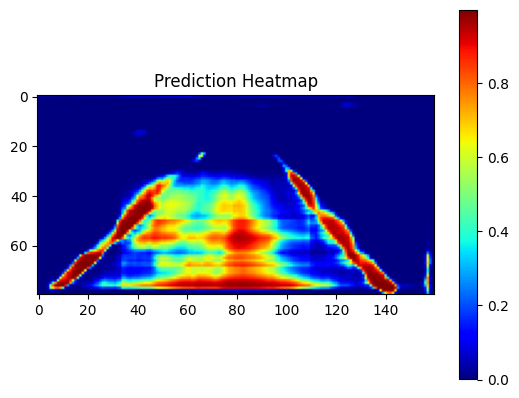

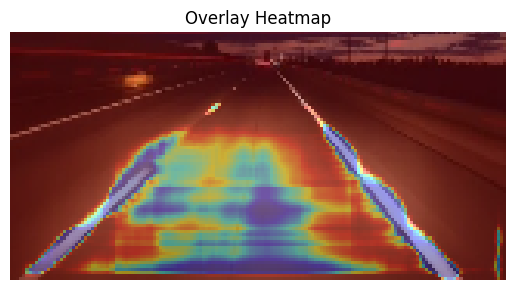

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("/content/drive/MyDrive/LLDNet-main/LLDNet-main/nighttimetest.jpg")

# Resize to model input
img = cv2.resize(img, (160, 80))

# Convert BGR → RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Normalize
img = img.astype(np.float32) / 255.0

# Add batch dimension
img_input = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(img_input)[0, :, :, 0]

# -----------------------------
# 🔥 HEATMAP
# -----------------------------
plt.imshow(pred, cmap='jet')
plt.title("Prediction Heatmap")
plt.colorbar()
plt.show()

# -----------------------------
# 🔥 OVERLAY HEATMAP
# -----------------------------
heatmap = cv2.applyColorMap(
    np.uint8(255 * pred),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    (img * 255).astype(np.uint8),
    0.6,
    heatmap,
    0.4,
    0
)

plt.imshow(overlay)
plt.title("Overlay Heatmap")
plt.axis('off')
plt.show()

In [ ]:
for layer in model.layers:
    print(layer.name)

input_1
conv2d
batch_normalization
conv2d_2
conv2d_1
add
re_lu
batch_normalization_1
pool1
conv2d_3
batch_normalization_2
conv2d_5
conv2d_4
add_1
re_lu_1
batch_normalization_3
pool2
conv2d_6
batch_normalization_4
conv2d_8
conv2d_7
add_2
re_lu_2
batch_normalization_5
pool3
conv2d_9
batch_normalization_6
conv2d_11
conv2d_10
add_3
re_lu_3
batch_normalization_7
pool4
global_average_pooling2d_3
global_max_pooling2d_3
global_average_pooling2d_1
global_max_pooling2d_1
global_average_pooling2d_2
global_max_pooling2d_2
dense_6
global_average_pooling2d
global_max_pooling2d
dense_2
dense_4
dense_7
dense
dense_3
dense_5
add_7
dense_1
add_5
add_6
activation_6
add_4
activation_2
activation_4
reshape_3
activation
reshape_1
reshape_2
multiply_6
reshape
multiply_2
multiply_4
average_pooling2d_3
max_pooling2d_3
multiply
average_pooling2d_1
max_pooling2d_1
average_pooling2d_2
max_pooling2d_2
concatenate_4
average_pooling2d
max_pooling2d
concatenate_1
concatenate_3
conv2d_15
concatenate
conv2d_13
conv2d_1

In [ ]:
last_conv = "conv2d_10"

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def gradcam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap.numpy()

In [ ]:
import os

size = os.path.getsize("/content/drive/MyDrive/Lanedetection/LLDNet_CBAM_trained.h5") / (1024*1024)
print(f"Model Size: {size:.2f} MB")

Model Size: 5.19 MB
